# Regression_Dropout_Layers_in_ANN

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

In [3]:
from keras import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import SGD, Adam
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy

# Make Dataset

In [4]:
# Train Data
X_train = np.linspace(-1, 1, 20)
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

# Test Data
X_test = np.linspace(-1, 1, 20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

# Plot Dataset

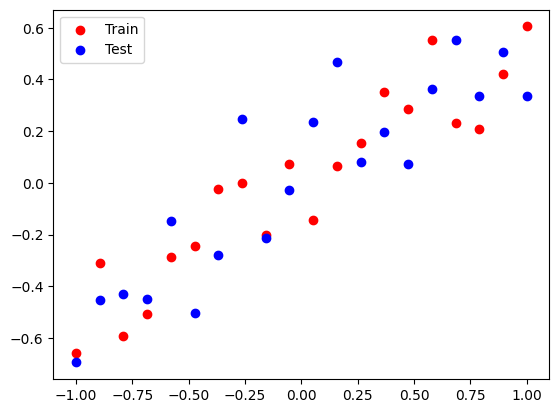

In [5]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

# Simple Regression Model

## Model Build

In [6]:
X_train.shape

(20,)

In [7]:
model1 = Sequential()
model1.add(Input(shape=(1,)))

model1.add(Dense(256, activation='relu'))
model1.add(Dense(512, activation='relu'))
model1.add(Dense(256, activation='relu'))

model1.add(Dense(1, activation='linear'))

In [8]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,681 (1.01 MB)

 Trainable params: 263,681 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compile

In [9]:
model1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mse']
)

## Model Training

In [10]:
history1 = model1.fit(
    x=X_train,
    y=y_train,
    epochs=500,
    validation_data = (X_test, y_test),
    verbose=0
)

## evaluate the model

In [11]:
_, train_mse = model1.evaluate(X_train, y_train, verbose=0)
_, test_mse = model1.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 3.052319516427815e-05, Test: 0.04427517205476761


## Plot Data

In [12]:
y_pred_1 = model1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


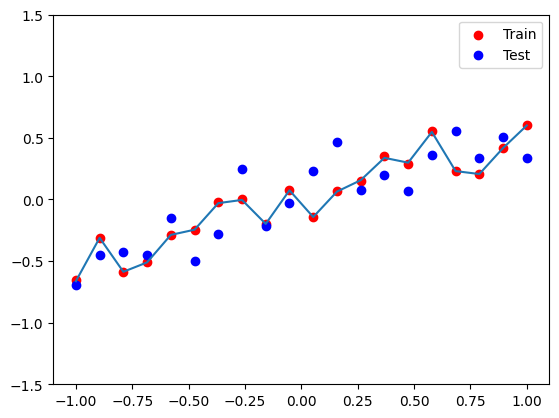

In [13]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

# Dropout Model

In [14]:
model2 = Sequential()
model2.add(Input(shape=(1,)))

model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.3))

model2.add(Dense(512, activation='relu'))
model2.add(Dropout(0.5))

model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.3))

model2.add(Dense(1, activation='linear'))

## Model Compile

In [15]:
model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mse']
)

## Model Training

In [16]:
history2 = model2.fit(
    x=X_train,
    y=y_train,
    epochs=500,
    validation_data = (X_test, y_test),
    verbose=0
)

## evaluate the model

In [17]:
_, train_mse = model2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.013351899571716785, Test: 0.039046578109264374


## Plot Data

In [18]:
y_pred_2 = model2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


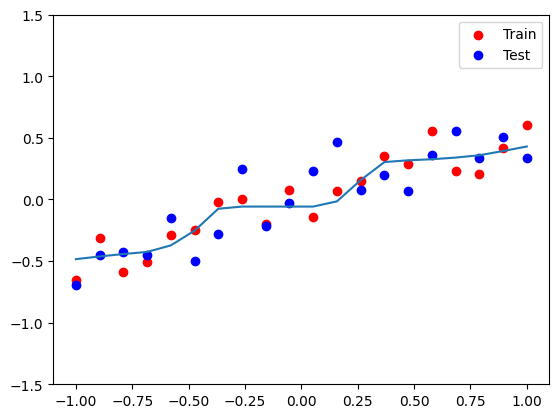

In [19]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()